In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.autograd.functional import hessian
import torch.optim as optim

In [296]:
def plotUnc(iX,iY,iPars,iModel,iH_inv,iPlot=True,iColor="r"):
    # Test inputs
    x_out_sort,sort = torch.sort(iX,axis=0)
    y_in_sort  = iY[sort]
    y_out_sort = iModel(x_out_sort,iPars).detach().numpy()
    y_pred_std = []

    for x in x_out_sort:
        # Define scalar output function at this x
        def f(p):
            return iModel(x.unsqueeze(0), p).squeeze()

        # Compute gradient w.r.t. parameters
        grad_fx = torch.autograd.grad(f(iPars), iPars, retain_graph=True)[0].unsqueeze(0)
        var_fx = grad_fx @ iH_inv @ grad_fx.T
        std_fx = torch.sqrt(var_fx).item()
        y_pred_std.append(std_fx)

    y_pred_std = np.array(y_pred_std)

    # Plot
    if iPlot:
        #plt.figure(figsize=(8,6))
        #plt.plot(iX.numpy(), iY.numpy(), 'bo', label="Training Data")
        plt.plot(x_out_sort.numpy(), y_out_sort, color=iColor)
        plt.fill_between(x_out_sort.numpy().flatten(),
                         y_out_sort.flatten() - y_pred_std,
                         y_out_sort.flatten() + y_pred_std,
                         color=iColor, alpha=0.3)
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        #plt.show()
        
        #resid=(iY.numpy()-y_out_sort)
        #plt.hist(resid)
        #plt.show()
        #print("mean:",resid.mean(),"+/-",resid.std())        
        
    return x_out_sort,y_out_sort,y_pred_std,y_in_sort
    

In [314]:
class CustomAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), xi=1.0, eps=1e-8, weight_decay=1e-3, clip_thresh=1.0,option=1): #clip -1
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.clip_thresh = clip_thresh
        self.option = option
        self.xi = xi
        
        # Initialize moment estimates and step counter
        self.m  = [torch.zeros_like(p) for p in self.params]
        self.v  = [torch.zeros_like(p) for p in self.params]
        self.v2 = [torch.zeros_like(p) for p in self.params]
        self.t = 0  # time step

    def step(self):
        self.t += 1
        for i, param in enumerate(self.params):
            if param.grad is None:
                continue

            grad = param.grad
            if self.weight_decay != 0:
                grad = grad + self.weight_decay * param 

            # Update biased first and second moment estimates
            grad2 = torch.sum(grad**2)*self.xi
            self.m[i]  = self.beta1 * self.m[i]  + (1 - self.beta1) * grad
            self.v[i]  = self.beta2 * self.v[i]  + (1 - self.beta2) * grad.pow(2)
            self.v2[i] = self.beta2 * self.v2[i] + (1 - self.beta2) * grad2
            
            # Compute bias-corrected estimates
            m_hat  = self.m[i]  / (1 - self.beta1 ** self.t)
            v_hat  = self.v[i]  / (1 - self.beta2 ** self.t)
            v2_hat = self.v2[i] / (1 - self.beta2 ** self.t)
            
            #
            if self.option == 0:
                update = m_hat / (v_hat.sqrt() + self.eps)
            else: 
                v_corr = 1./(1. + torch.abs(v2_hat) + self.eps)
                update = m_hat * v_corr
            update_norm = update.norm()
            if update_norm > self.clip_thresh and self.clip_thresh > 0:
                update = update * (self.clip_thresh / update_norm)
            
            # Parameter update
            param.data -= self.lr * update
            
    
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()


In [147]:
def train_basic(iX,iY,iNEpoch,iModel,iParams,iLoss,iOption=0,lr=1e-3):
    #pars=iParams.clone()
    optimizer = CustomAdam([iParams],lr=lr,option=iOption)#optim.Adam([iParams], lr=1e-2)
    loss_out=[]
    for epoch in range(iNEpoch):
        optimizer.zero_grad()
        y_pred = iModel(iX, iParams)
        loss   = iLoss(y_pred, iY, iParams)
        loss.backward()
        optimizer.step()
        loss_out.append(loss.item())
        if epoch % 500 == 0:
            print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")
    def closuref(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, [])
    H_final = hessian(closuref, iParams)
    return H_final,iParams,loss_out


In [46]:
# Hessian-vector product
def hvp(grad, model, v, pars):
    hv = torch.autograd.grad(grad, pars, grad_outputs=v, retain_graph=True)
    return torch.cat([h.contiguous().view(-1) for h in hv])

# Compute tau for trust region boundary
def solve_trust_boundary(x, p, delta):
    a = torch.dot(p, p)
    b = 2 * torch.dot(x, p)
    c = torch.dot(x, x) - delta**2
    tau = (-b + torch.sqrt(b**2 - 4*a*c)) / (2*a)
    return tau

# Truncated Conjugate Gradient for Trust Region
def truncated_cg(grad, hvp_func, trust_radius, pars, max_iter=50):
    x = torch.zeros_like(grad)
    r = -grad.clone()
    p = r.clone()
    rs_old = torch.dot(r, r)

    for i in range(max_iter):
        Hp = hvp_func(p)
        alpha = rs_old / (torch.dot(p, Hp) + 1e-10)

        x_new = x + alpha * p

        if torch.norm(x_new) > trust_radius:
            # Step hits the boundary of the trust region
            tau = solve_trust_boundary(x, p, trust_radius)
            return x + tau * p

        x = x_new
        r = r - alpha * Hp
        rs_new = torch.dot(r, r)
        if rs_new.sqrt() < 1e-8:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x

def train(iX,iY,iNEpoch,iModel,iParams,iLoss,dampingconst=1e-3):
    def closure(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, p)
    H_damped = 0
    #pars=iParams.clone()
    delta=1.0
    dampingconst0=dampingconst
    loss_out=[]
    for epoch in range(iNEpoch):
        # Compute gradient
        loss = closure(iParams)
        grad = torch.autograd.grad(loss, iParams, create_graph=True)[0]

        # Compute Hessian
        #H = hessian(closure, iParams)
        # Damping for stability
        #damping = dampingconst0 * torch.eye(H.shape[0])
        #H_damped = H + damping

        #newton-cg
        def hv_func(v):
            return hvp(grad, iModel, v, iParams)
        step = truncated_cg(grad, hv_func, delta, iParams)
        iParams = iParams + step*dampingconst
        
        #trust step
        #step = solve_trust_region2(H_damped, grad, delta)
        #pars = pars - step
        
        # Newton step
        #delta = -torch.linalg.solve(H_damped, grad.detach())
        #iParams = (iParams.detach() + delta).requires_grad_()
        
        new_loss = closure(iParams)
        if loss.item()-new_loss.item() > 0:
            delta *= 1.5  # Increase trust radius
            dampingconst0 *= 0.8  # Reduce damping
        else:
            delta *= 0.5  # Shrink trust radius
            dampingconst0 *= 1.5  # Increase damping
        loss_out.append(loss.item())
        if epoch % 25 == 0:
            print(f"Epoch {epoch+1}: Loss = {closure(iParams).item():.4f}")
    def closuref(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, [])
    H_final = hessian(closuref, iParams)
    return H_final,iParams,loss_out

In [313]:
# Define a simple neural network (functional form)
class SimpleNN(nn.Module):
    def __init__(self,nhidden=10,nlayers=2):
        super(SimpleNN, self).__init__()
        self.shapes = []#[ (1,nhidden), (nhidden,), (nhidden,1), (1,) ]  # Layer shapes
        self.shapes.append((1,nhidden))
        self.shapes.append((nhidden,))
        for pVal in range(nlayers-2):
            self.shapes.append((nhidden,nhidden))
            self.shapes.append((nhidden,))
        self.shapes.append((nhidden,1))
        self.shapes.append((1,))
        self.nhidden = nhidden
        self.nlayers = nlayers
        self.total_params = sum([torch.tensor(s).prod() for s in self.shapes])
        self.act     = torch.nn.SiLU()
        #self.act     = torch.nn.ReLU()
        #self.act     = torch.nn.GELU()
    
    def forward(self, x, params):
        idx = 0
        W1 = params[idx:idx+1*self.nhidden].reshape(1,self.nhidden)
        idx += 1*self.nhidden
        b1 = params[idx:idx+self.nhidden].reshape(self.nhidden)
        idx += self.nhidden
        x    =  self.act(x @ W1 + b1) 
        for pVal in range(self.nlayers-2):
            Wx   =  params[idx:idx+self.nhidden*self.nhidden].reshape(self.nhidden,self.nhidden)
            idx  += self.nhidden*self.nhidden
            bx   =  params[idx:idx+self.nhidden*1].reshape(self.nhidden)
            idx  += self.nhidden
            x    =  self.act(x @ Wx + bx)    
        W2 = params[idx:idx+self.nhidden*1].reshape(self.nhidden,1)
        idx += self.nhidden*1
        b2 = params[idx:idx+1].reshape(1)
        x = x @ W2 + b2
        return x

# Simple MLP
class SimpleNet(nn.Module):
    def __init__(self,nhidden=10,nlayers=2):
        super().__init__()
        self.act = torch.nn.SiLU()
        self.arr = []
        self.arr.append(nn.Linear(1,nhidden))
        self.arr.append(self.act)
        for pLayer in range(nlayers-2):
            self.arr.append(nn.Linear(nhidden,nhidden))
            self.arr.append(self.act)
        self.arr.append(nn.Linear(nhidden,1))
        self.arr.append(self.act)
        self.net = nn.Sequential(
            *self.arr
        )

    def forward(self, x):
        return self.net(x)

    
class poly(nn.Module):
    def __init__(self,npars=3):
        super(poly, self).__init__()
        self.shapes = [ (npars,) ]  # Layer shapes
        self.total_params = sum([torch.tensor(s).prod() for s in self.shapes])
        self.npars = npars
    
    def forward(self, x, params):
        x1 = params[0] + params[1]*x + params[2]*(x**2)
        if self.npars > 3:
            x1 += params[3]*(x**3)
        if self.npars > 4:
            x1 += params[4]*(x**4)
        if self.npars > 5:
            x1 += params[5]*(x**5)
        return x1
    

class LogLikeLoss(nn.Module):
    def __init__(self,sigma=1,l2reg=1e-3):
        super(LogLikeLoss, self).__init__()
        self.sigma = sigma
        self.l2reg = l2reg
        
    def forward(self, y_pred, y_true,params=0):
        squared_difference = ((1./self.sigma)**2)*(y_true - y_pred)**2
        loss = torch.mean(squared_difference)
        if len(params) > 0:
            loss += self.l2reg*torch.sum(params**2) 
        return loss


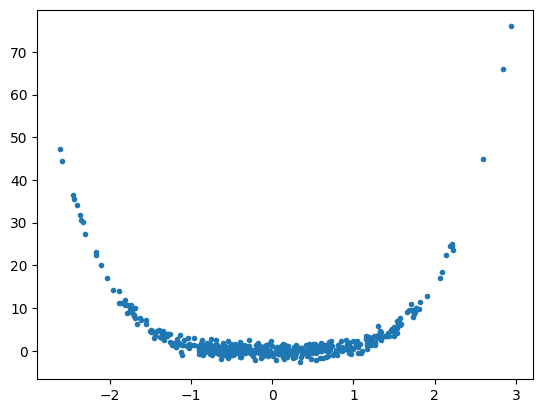

In [134]:
x_train = torch.randn(500,1)
y_train = x_train**4 +  torch.randn(500,1)
plt.plot(x_train,y_train,'.')

Epoch 1: Loss = 21.4303
Epoch 26: Loss = 0.8793
Epoch 51: Loss = 0.8793
Epoch 1: Loss = 462.0438
Epoch 1: Loss = 462.0438


/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/ipykernel_70270/1222163981.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


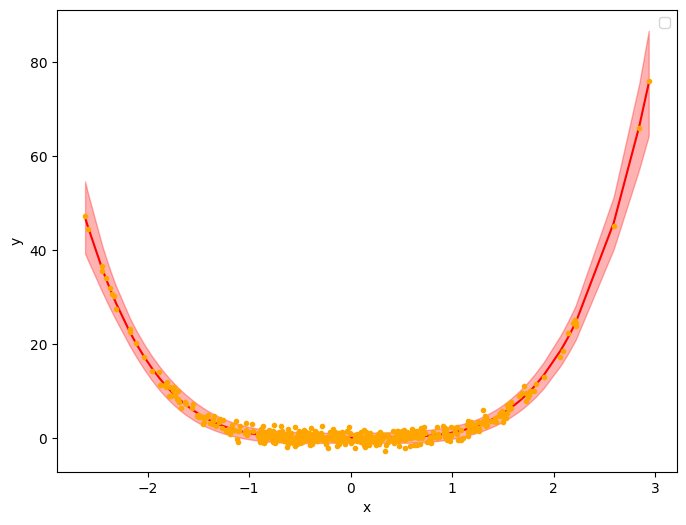

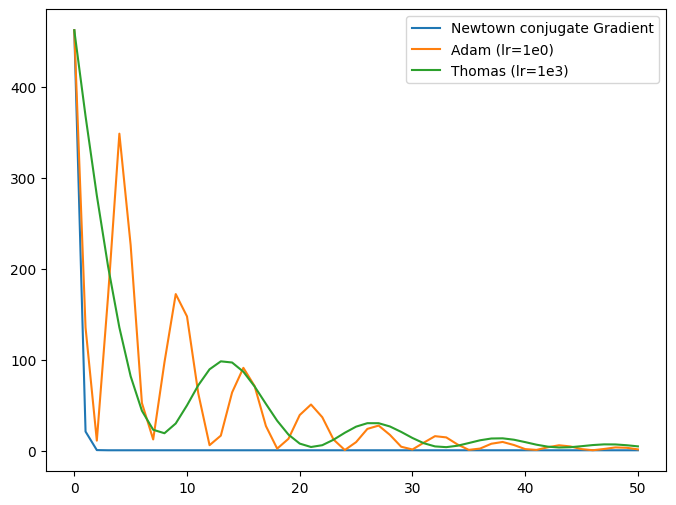

In [328]:
model1  = poly(npars=6)
model2  = poly(npars=6)#SimpleNN(nhidden=3,nlayers=3)
model3  = poly(npars=6)#SimpleNN(nhidden=3,nlayers=3)
seed=121
torch.manual_seed(seed)
params1 = torch.randn(model1.total_params, requires_grad=True)
torch.manual_seed(seed)
params2 = torch.randn(model2.total_params, requires_grad=True)
torch.manual_seed(seed)
params3 = torch.randn(model3.total_params, requires_grad=True)
loss_fn = LogLikeLoss(sigma=1.,l2reg=0)
H1_out,pars1_out,loss1=train(x_train,y_train,51,model1,params1,loss_fn,dampingconst=1e0)
H2_out,pars2_out,loss2=train_basic(x_train,y_train,51,model2,params2,loss_fn,iOption=0,lr=1e0)
H3_out,pars3_out,loss3=train_basic(x_train,y_train,51,model3,params3,loss_fn,iOption=1,lr=1e2)
#x_out_sort = torch.sort(x_train,axis=0)[0]
#y_out_sort = model(x_out_sort,pars_out).detach().numpy()
#plt.plot(x_train,y_train,'.')
#plt.plot(x_out_sort,y_out_sort,'--',c='r')
#print(torch.sort(pars2_out)[0][0:10])

H1_inv = torch.linalg.inv(H1_out).detach()
H2_inv = torch.linalg.inv(H2_out).detach()
H3_inv = torch.linalg.inv(H3_out).detach()
#print(H_inv,pars_out)
#eigv,eigvec=np.linalg.eig(H_inv)
#print(eigv,eigv)
plt.figure(figsize=(8,6))
x1_out,y1_out,y1_std,y1_in = plotUnc(x_train,y_train,pars1_out,model1,H1_inv)
#x2_out,y2_out,y2_std,y2_in = plotUnc(x_train,y_train,pars2_out,model2,H2_inv,iColor='green')
#x3_out,y3_out,y3_std,y3_in = plotUnc(x_train,y_train,pars3_out,model2,H3_inv,iColor='blue')
plt.plot(x_train,y_train,'.',color='orange')

plt.show()
#print(H2_inv)

plt.figure(figsize=(8,6))
plt.plot(loss1,label="Newtown conjugate Gradient")
plt.plot(loss2,label="Adam (lr=1e0)")
plt.plot(loss3,label="Thomas (lr=1e3)")
plt.legend()
plt.show()

Epoch 1: Loss = 52.8474
Epoch 26: Loss = 1.7891
Epoch 51: Loss = 1.8714
Epoch 76: Loss = 3.9691
Epoch 101: Loss = 0.9605
Epoch 1: Loss = 52.1167
Epoch 1: Loss = 52.1167


/var/folders/4t/mwl83f3x1ls0jvy35v4qzj7c0000gp/T/ipykernel_70270/1222163981.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


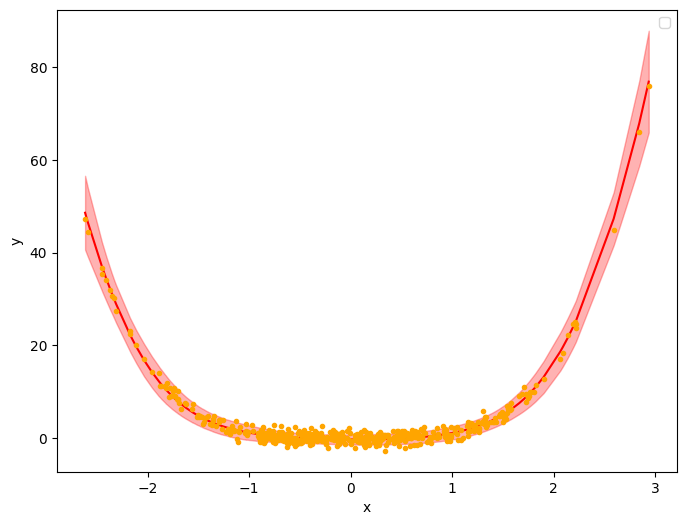

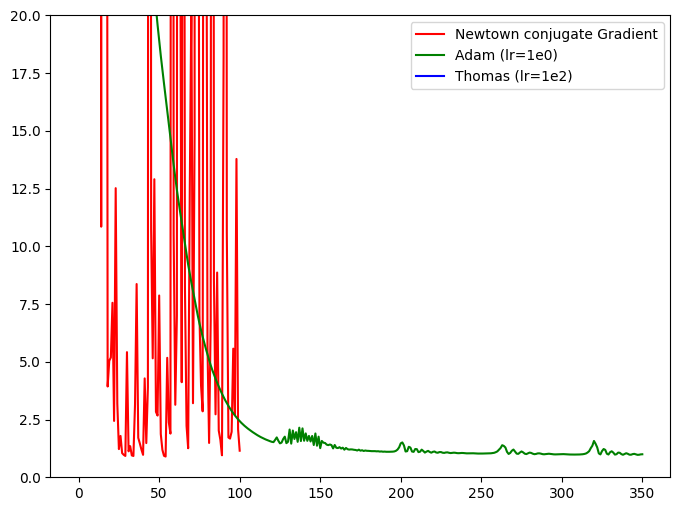

In [327]:
model1  = SimpleNN(nhidden=4,nlayers=4)
model2  = SimpleNN(nhidden=4,nlayers=4)
model3  = SimpleNN(nhidden=4,nlayers=4)
seed=121
torch.manual_seed(seed)
params1 = torch.randn(model1.total_params, requires_grad=True)
torch.manual_seed(seed)
params2 = torch.randn(model2.total_params, requires_grad=True)
torch.manual_seed(seed)
params3 = torch.randn(model3.total_params, requires_grad=True)
loss_fn = LogLikeLoss(sigma=1.,l2reg=0)
H1_out,pars1_out,loss1=train(x_train,y_train,101,model1,params1,loss_fn,dampingconst=0.9999)
H2_out,pars2_out,loss2=train_basic(x_train,y_train,351,model2,params2,loss_fn,iOption=0,lr=1e-1)
H3_out,pars3_out,loss3=train_basic(x_train,y_train,351,model3,params3,loss_fn,iOption=1,lr=1e2)
#x_out_sort = torch.sort(x_train,axis=0)[0]
#y_out_sort = model(x_out_sort,pars_out).detach().numpy()
#plt.plot(x_train,y_train,'.')
#plt.plot(x_out_sort,y_out_sort,'--',c='r')
#print(torch.sort(pars2_out)[0][0:10])

H1_inv = torch.linalg.inv(H1_out).detach()
H2_inv = torch.linalg.inv(H2_out).detach()
H3_inv = torch.linalg.inv(H3_out).detach()
plt.figure(figsize=(8,6))
x1_out,y1_out,y1_std,y1_in = plotUnc(x_train,y_train,pars1_out,model1,H1_inv,iColor='red')
#x2_out,y2_out,y2_std,y2_in = plotUnc(x_train,y_train,pars2_out,model2,H2_inv,iColor='green')
#x3_out,y3_out,y3_std,y3_in = plotUnc(x_train,y_train,pars3_out,model2,H3_inv,iColor='blue')
plt.plot(x_train,y_train,'.',color='orange')
plt.show()

plt.figure(figsize=(8,6))
plt.plot(loss1,label="Newtown conjugate Gradient",color='red')
plt.plot(loss2,label="Adam (lr=1e0)",color='green')
plt.plot(loss3,label="Thomas (lr=1e2)",color='blue')
plt.ylim(0,20)
plt.legend()
plt.show()